<a href="https://colab.research.google.com/github/SMvarre/Deep_Learning_0403/blob/main/DL403.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#AND GATE

In [2]:
import numpy as np

# -------------------------
# Parameters
# -------------------------
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# -------------------------
# AND Gate Dataset
# -------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [0], [0], [1]])

# -------------------------
# Initialization
# -------------------------
np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))
bias = np.array([[0.0]])

print("Initial Weights and Bias")
print("Weights:", weights.flatten())
print("Bias:", bias[0, 0])

# -------------------------
# Activation Functions
# -------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

def predict(X, weights, bias):
    return sigmoid(np.dot(X, weights) + bias)

# -------------------------
# Training
# -------------------------
print("\nTraining Single Neuron (AND Gate)...")

for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    loss = np.mean(np.abs(error))

    if iteration % print_interval == 0:
        print(f"Iteration {iteration}: Loss = {loss:.4f}")

# -------------------------
# Results
# -------------------------
print("\nTraining Complete!")
print(f"Final Weights: W1={weights[0,0]:.3f}, W2={weights[1,0]:.3f}")
print(f"Final Bias: {bias[0,0]:.3f}")

final_predictions = predict(X, weights, bias)

print("\nPredictions (AND Gate):")
for i in range(len(X)):
    pred_class = 1 if final_predictions[i, 0] > 0.5 else 0
    print(f"Input {X[i]} → {final_predictions[i,0]:.3f} ({pred_class})")

Initial Weights and Bias
Weights: [-0.25091976  0.90142861]
Bias: 0.0

Training Single Neuron (AND Gate)...
Iteration 0: Loss = 0.4979
Iteration 1000: Loss = 0.3525
Iteration 2000: Loss = 0.2996

Training Complete!
Final Weights: W1=1.315, W2=1.454
Final Bias: -2.272

Predictions (AND Gate):
Input [0 0] → 0.093 (0)
Input [0 1] → 0.306 (0)
Input [1 0] → 0.277 (0)
Input [1 1] → 0.622 (1)


In [ ]:
#hardcoded and gate

In [ ]:
import numpy as np

# Input and output for AND gate
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [0],
    [0],
    [1]
])

print("AND GATE SINGLE PERCEPTRON HARD-CODED WEIGHTS")
print("=" * 60)

# Hard-coded weights and bias
weights = np.array([[1.0],
                    [1.0]])
bias = np.array([[-1.5]])

print(f"Weights: w1={weights[0,0]:.1f}, w2={weights[1,0]:.1f}")
print(f"Bias: b={bias[0,0]:.1f}")
print(f"Equation: 1*x1 + 1*x2 - 1.5 > 0")

# Step activation function
def step_function(x):
    return 1 if x > 0 else 0

# Perceptron prediction
def perceptron_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    predictions = np.zeros((len(X), 1))
    for i in range(len(linear)):
        predictions[i, 0] = step_function(linear[i, 0])
    return predictions

print("\nPREDICTIONS")
linear_values = np.dot(X, weights) + bias
predictions = perceptron_predict(X, weights, bias)

for i in range(len(X)):
    linear_val = linear_values[i, 0]
    pred = predictions[i, 0]
    actual = y[i, 0]
    print(f"[{X[i,0]}, {X[i,1]}] → Linear: {linear_val:5.1f} → "
          f"Predicted: {int(pred)} | Actual: {int(actual)}")

print("\nVERIFICATION RESULTS")
print("Linear values for each input:")

for i in range(len(X)):
    z = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
    print(f"[{X[i,0]}, {X[i,1]}]: z = {z:.1f} → "
          f"{'Class 1' if z > 0 else 'Class 0'}")

# print("\nPoint positions relative to decision boundary:")
# for i in range(len(X)):
#     point_value = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
#     side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
#     print(f"[{X[i,0]}, {X[i,1]}]: {point_value:.3f} → {side}")


AND GATE SINGLE PERCEPTRON HARD-CODED WEIGHTS
Weights: w1=1.0, w2=1.0
Bias: b=-1.5
Equation: 1*x1 + 1*x2 - 1.5 > 0

PREDICTIONS
[0, 0] → Linear:  -1.5 → Predicted: 0 | Actual: 0
[0, 1] → Linear:  -0.5 → Predicted: 0 | Actual: 0
[1, 0] → Linear:  -0.5 → Predicted: 0 | Actual: 0
[1, 1] → Linear:   0.5 → Predicted: 1 | Actual: 1

VERIFICATION RESULTS
Linear values for each input:
[0, 0]: z = -1.5 → Class 0
[0, 1]: z = -0.5 → Class 0
[1, 0]: z = -0.5 → Class 0
[1, 1]: z = 0.5 → Class 1

Point positions relative to decision boundary:
[0, 0]: -1.500 → Below (Class 0)
[0, 1]: -0.500 → Below (Class 0)
[1, 0]: -0.500 → Below (Class 0)
[1, 1]: 0.500 → Above (Class 1)


In [ ]:
#or gate

In [ ]:
import numpy as np

input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [1]])

np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))
## Creates: [[w1], [w2]] where w1, w2 ∈ [-1, 1)
bias = np.array([[0.0]])

print("Bias is ", bias[0,0])
print("Initial Weights + Bias:")
print(f"Weights: {weights.flatten()}")
print(f"Bias: {bias[0,0]:.3f}")

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

def predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return sigmoid(linear)

print("\nTraining Single Perceptron (OR Gate)...")

loss_history = []

for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    current_loss = np.mean(np.abs(error))
    loss_history.append(current_loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration:4d}: Loss = {current_loss:.4f}")

print("\nTraining Complete!")
print(f"Final Weights: W1={weights[0][0]:.3f}, W2={weights[1][0]:.3f}")
print(f"Final Bias: {bias[0][0]:.3f}")

final_predictions = predict(X, weights, bias)

print("\nPredictions (OR Gate):")
for i in range(len(X)):
    pred_class = 1 if final_predictions[i][0] > 0.5 else 0
    print(f"Input: [{X[i][0]},{X[i][1]}] → "
          f"Pred: {final_predictions[i][0]:.3f} ({pred_class})")

print("\nDECISION BOUNDARY VERIFICATION:")
print(f"Equation: {weights[0,0]:.3f}x1 + {weights[1,0]:.3f}x2 + {bias[0,0]:.3f} = 0")

print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f"[{X[i,0]},{X[i,1]}]: {point_value:.3f} → {side}")


Bias is  0.0
Initial Weights + Bias:
Weights: [-0.25091976  0.90142861]
Bias: 0.000

Training Single Perceptron (OR Gate)...
Iteration    0: Loss = 0.4235
Iteration 1000: Loss = 0.2693
Iteration 2000: Loss = 0.2290

Training Complete!
Final Weights: W1=1.818, W2=2.053
Final Bias: -0.531

Predictions (OR Gate):
Input: [0,0] → Pred: 0.370 (0)
Input: [0,1] → Pred: 0.821 (1)
Input: [1,0] → Pred: 0.784 (1)
Input: [1,1] → Pred: 0.966 (1)

DECISION BOUNDARY VERIFICATION:
Equation: 1.818x1 + 2.053x2 + -0.531 = 0

Point positions relative to boundary:
[0,0]: -0.531 → Below (Class 0)
[0,1]: 1.522 → Above (Class 1)
[1,0]: 1.287 → Above (Class 1)
[1,1]: 3.339 → Above (Class 1)


In [ ]:
#hard coded or gate

In [ ]:
import numpy as np

# Input combinations for OR gate
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Expected outputs for OR gate
y = np.array([
    [0],
    [1],
    [1],
    [1]
])

print("OR GATE SINGLE PERCEPTRON - HARD-CODED WEIGHTS")
print("=" * 60)

# Hard-coded weights and bias
weights = np.array([[1.0],
                    [1.0]])
bias = np.array([[-0.5]])

print(f"Weights: w1={weights[0,0]:.1f}, w2={weights[1,0]:.1f}")
print(f"Bias: b={bias[0,0]:.1f}")
print("Equation: 1*x1 + 1*x2 - 0.5 > 0")

# Step activation function
def step_function(x):
    return 1 if x > 0 else 0

# Perceptron prediction function
def perceptron_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    predictions = np.zeros((len(X), 1))
    for i in range(len(linear)):
        predictions[i, 0] = step_function(linear[i, 0])
    return predictions

# Prediction
print("\nPREDICTIONS")
linear_values = np.dot(X, weights) + bias
predictions = perceptron_predict(X, weights, bias)

for i in range(len(X)):
    print(f"[{X[i,0]}, {X[i,1]}] → Linear: {linear_values[i,0]:5.1f} → "
          f"Predicted: {int(predictions[i,0])} | Actual: {int(y[i,0])}")

# Verification
print("\nVERIFICATION RESULTS")
print("Linear values for each input:")

for i in range(len(X)):
    z = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
    print(f"[{X[i,0]}, {X[i,1]}]: z = {z:.1f} → "
          f"{'Class 1' if z > 0 else 'Class 0'}")

print("\nPoint positions relative to decision boundary:")
for i in range(len(X)):
    point_value = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f"[{X[i,0]}, {X[i,1]}]: {point_value:.3f} → {side}")


OR GATE SINGLE PERCEPTRON - HARD-CODED WEIGHTS
Weights: w1=1.0, w2=1.0
Bias: b=-0.5
Equation: 1*x1 + 1*x2 - 0.5 > 0

PREDICTIONS
[0, 0] → Linear:  -0.5 → Predicted: 0 | Actual: 0
[0, 1] → Linear:   0.5 → Predicted: 1 | Actual: 1
[1, 0] → Linear:   0.5 → Predicted: 1 | Actual: 1
[1, 1] → Linear:   1.5 → Predicted: 1 | Actual: 1

VERIFICATION RESULTS
Linear values for each input:
[0, 0]: z = -0.5 → Class 0
[0, 1]: z = 0.5 → Class 1
[1, 0]: z = 0.5 → Class 1
[1, 1]: z = 1.5 → Class 1

Point positions relative to decision boundary:
[0, 0]: -0.500 → Below (Class 0)
[0, 1]: 0.500 → Above (Class 1)
[1, 0]: 0.500 → Above (Class 1)
[1, 1]: 1.500 → Above (Class 1)


In [ ]:
#xor gate

In [ ]:
import numpy as np

# -------------------------
# XOR Dataset
# -------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

# -------------------------
# Parameters
# -------------------------
learning_rate = 0.1
epochs = 10000

# -------------------------
# Initialization
# -------------------------
np.random.seed(42)

# Weights and biases
W1 = np.random.uniform(-1, 1, (2, 2))  # Input → Hidden
b1 = np.zeros((1, 2))

W2 = np.random.uniform(-1, 1, (2, 1))  # Hidden → Output
b2 = np.zeros((1, 1))

# -------------------------
# Activation Functions
# -------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

# -------------------------
# Training
# -------------------------
print("Training XOR Gate (2-Layer Neural Network)...")

for epoch in range(epochs):
    # Forward pass
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, W2) + b2
    output = sigmoid(final_input)

    # Error
    error = y - output

    # Backpropagation
    d_output = error * sigmoid_derivative(output)
    d_hidden = np.dot(d_output, W2.T) * sigmoid_derivative(hidden_output)

    # Update weights and biases
    W2 += learning_rate * np.dot(hidden_output.T, d_output)
    b2 += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    W1 += learning_rate * np.dot(X.T, d_hidden)
    b1 += learning_rate * np.sum(d_hidden, axis=0, keepdims=True)

    if epoch % 2000 == 0:
        loss = np.mean(np.abs(error))
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# -------------------------
# Testing
# -------------------------
print("\nPredictions (XOR Gate):")
for i in range(len(X)):
    pred = 1 if output[i, 0] > 0.5 else 0
    print(f"Input {X[i]} → {output[i,0]:.3f} ({pred})")

Training XOR Gate (2-Layer Neural Network)...
Epoch 0: Loss = 0.5005
Epoch 2000: Loss = 0.4998
Epoch 4000: Loss = 0.4985
Epoch 6000: Loss = 0.4200
Epoch 8000: Loss = 0.1565

Predictions (XOR Gate):
Input [0 0] → 0.096 (0)
Input [0 1] → 0.894 (1)
Input [1 0] → 0.894 (1)
Input [1 1] → 0.086 (0)


In [ ]:
#xor hardcoded

In [ ]:
import numpy as np

# -------------------------
# XOR Dataset
# -------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# -------------------------
# Hard-coded weights & bias
# -------------------------

# Hidden layer (2 neurons)
# Neuron 1 → OR gate
# Neuron 2 → NAND gate
W1 = np.array([
    [ 10, -10],
    [ 10, -10]
])
b1 = np.array([[-5, 15]])

# Output layer (AND of OR & NAND)
W2 = np.array([
    [10],
    [10]
])
b2 = np.array([[-15]])

# -------------------------
# Activation
# -------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# -------------------------
# Forward pass
# -------------------------
hidden_input = np.dot(X, W1) + b1
hidden_output = sigmoid(hidden_input)

final_input = np.dot(hidden_output, W2) + b2
output = sigmoid(final_input)

# -------------------------
# Results
# -------------------------
print("XOR Gate (Hard-Coded Weights)")
print("=" * 40)

for i in range(len(X)):
    pred = 1 if output[i, 0] > 0.5 else 0
    print(f"Input {X[i]} → {output[i,0]:.3f} ({pred})")


XOR Gate (Hard-Coded Weights)
Input [0 0] → 0.007 (0)
Input [0 1] → 0.992 (1)
Input [1 0] → 0.992 (1)
Input [1 1] → 0.007 (0)


In [ ]:
#BATCH GRADIENT DECENT

Epoch 0: Loss = 0.4884
Epoch 500: Loss = 0.2146

Final Predicted vs Actual:
Input [0 0] → Predicted: 0 | Actual: 0
Input [0 1] → Predicted: 0 | Actual: 0
Input [1 0] → Predicted: 0 | Actual: 0
Input [1 1] → Predicted: 1 | Actual: 1

Accuracy: 100.00%


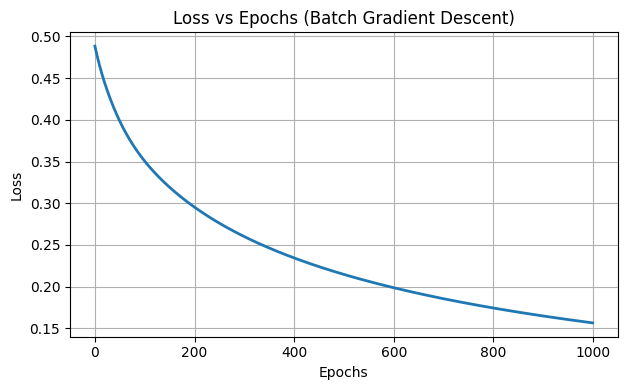

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Dataset (AND gate)
# -------------------------
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

# -------------------------
# Parameters
# -------------------------
lr = 0.1
epochs = 1000

np.random.seed(1)
weights = np.random.randn(2,1)
bias = 0.0

loss_history = []

# -------------------------
# Activation functions
# -------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

# -------------------------
# Training (Batch GD)
# -------------------------
for epoch in range(epochs):
    z = np.dot(X, weights) + bias
    output = sigmoid(z)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    weights += lr * np.dot(X.T, d_output)
    bias += lr * np.sum(d_output)

    loss = np.mean(np.abs(error))
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# -------------------------
# Final Predictions
# -------------------------
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output > 0.5).astype(int)

print("\nFinal Predicted vs Actual:")
for i in range(len(X)):
    print(f"Input {X[i]} → Predicted: {predicted[i][0]} | Actual: {y[i][0]}")

# -------------------------
# Accuracy Calculation
# -------------------------
accuracy = np.mean(predicted == y) * 100
print(f"\nAccuracy: {accuracy:.2f}%")

# -------------------------
# GRAPH 1: Loss vs Epochs
# -------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(loss_history, linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (Batch Gradient Descent)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
#Mini Batch Gradent descent


Epoch 0: Loss = 0.4857
Epoch 500: Loss = 0.2143

ACTUAL vs PREDICTED (Mini-Batch GD)
Input [0 0] | Actual: 0 | Predicted: 0 (value = 0.016)
Input [0 1] | Actual: 0 | Predicted: 0 (value = 0.189)
Input [1 0] | Actual: 0 | Predicted: 0 (value = 0.191)
Input [1 1] | Actual: 1 | Predicted: 1 (value = 0.770)



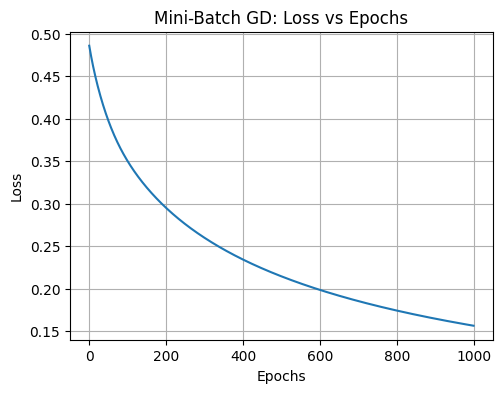

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset (AND gate)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

# Parameters
lr = 0.1
epochs = 1000
batch_size = 2

np.random.seed(1)
weights = np.random.randn(2,1)
bias = 0.0

loss_history = []

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

# Training
for epoch in range(epochs):
    for i in range(0, len(X), batch_size):
        Xb = X[i:i+batch_size]
        yb = y[i:i+batch_size]

        z = np.dot(Xb, weights) + bias
        output = sigmoid(z)

        error = yb - output
        d_output = error * sigmoid_derivative(output)

        weights += lr * np.dot(Xb.T, d_output)
        bias += lr * np.sum(d_output)

    loss = np.mean(np.abs(y - sigmoid(np.dot(X,weights)+bias)))
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# Final prediction
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output > 0.5).astype(int)

print("\nACTUAL vs PREDICTED (Mini-Batch GD)")
for i in range(len(X)):
    print(f"Input {X[i]} | Actual: {y[i][0]} | "
          f"Predicted: {predicted[i][0]} "
          f"(value = {final_output[i][0]:.3f})")
print()
# Plots
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Mini-Batch GD: Loss vs Epochs")
plt.grid(True)

plt.show()


In [ ]:
#stochastic gradient descent

Epoch 0: Loss = 0.4857
Epoch 500: Loss = 0.2139

ACTUAL vs PREDICTED (SGD)
Input [0 0] | Actual: 0 | Predicted: 0 (value = 0.016)
Input [0 1] | Actual: 0 | Predicted: 0 (value = 0.189)
Input [1 0] | Actual: 0 | Predicted: 0 (value = 0.190)
Input [1 1] | Actual: 1 | Predicted: 1 (value = 0.771)



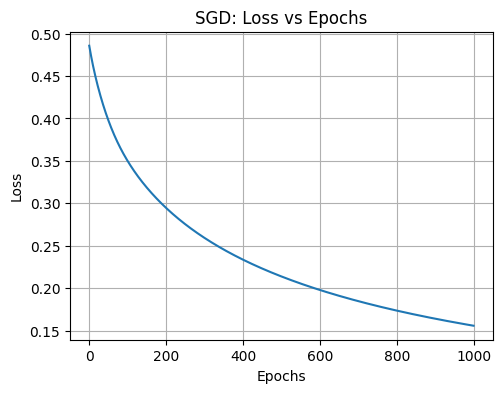

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

lr = 0.1
epochs = 1000

np.random.seed(1)
weights = np.random.randn(2,1)
bias = 0.0

loss_history = []

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

# Training
for epoch in range(epochs):
    for i in range(len(X)):
        xi = X[i].reshape(1,-1)
        yi = y[i]

        z = np.dot(xi, weights) + bias
        output = sigmoid(z)

        error = yi - output
        d_output = error * sigmoid_derivative(output)

        weights += lr * np.dot(xi.T, d_output)
        bias += lr * d_output[0,0]

    loss = np.mean(np.abs(y - sigmoid(np.dot(X,weights)+bias)))
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# Final prediction
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output > 0.5).astype(int)

print("\nACTUAL vs PREDICTED (SGD)")
for i in range(len(X)):
    print(f"Input {X[i]} | Actual: {y[i][0]} | "
          f"Predicted: {predicted[i][0]} "
          f"(value = {final_output[i][0]:.3f})")
print()
# Plots
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("SGD: Loss vs Epochs")
plt.grid(True)

plt.show()


In [ ]:
#momentum

Epoch 0: Loss = 0.4884
Epoch 500: Loss = 0.0635

ACTUAL vs PREDICTED (Momentum GD)
Input [0 0] | Actual: 0 | Predicted: 0 (value = 0.000)
Input [0 1] | Actual: 0 | Predicted: 0 (value = 0.055)
Input [1 0] | Actual: 0 | Predicted: 0 (value = 0.055)
Input [1 1] | Actual: 1 | Predicted: 1 (value = 0.935)



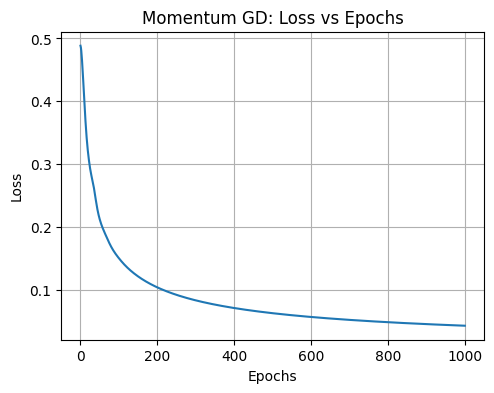

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[0],[0],[1]])

lr = 0.1
epochs = 1000
beta = 0.9

np.random.seed(1)
weights = np.random.randn(2,1)
bias = 0.0

vw = np.zeros_like(weights)
vb = 0.0
loss_history = []

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(y):
    return y * (1 - y)

# Training
for epoch in range(epochs):
    z = np.dot(X, weights) + bias
    output = sigmoid(z)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    grad_w = np.dot(X.T, d_output)
    grad_b = np.sum(d_output)

    vw = beta * vw + lr * grad_w
    vb = beta * vb + lr * grad_b

    weights += vw
    bias += vb

    loss = np.mean(np.abs(error))
    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

# Final prediction
final_output = sigmoid(np.dot(X, weights) + bias)
predicted = (final_output > 0.5).astype(int)

print("\nACTUAL vs PREDICTED (Momentum GD)")
for i in range(len(X)):
    print(f"Input {X[i]} | Actual: {y[i][0]} | "
          f"Predicted: {predicted[i][0]} "
          f"(value = {final_output[i][0]:.3f})")
print()
# Plots
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Momentum GD: Loss vs Epochs")
plt.grid(True)

plt.show()


In [ ]:
# Ridge Regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print(ridge.coef_)
print(ridge.score(X_test, y_test))

[60.80641691 96.97650095 59.85083263 54.82588222 35.69887237]
0.994006040552328


In [ ]:
# Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print(lasso.coef_)
print(lasso.score(X_test, y_test))

[61.43821843 98.34755587 60.9358236  55.43964642 35.89008021]
0.9944057177924089
